<a href="https://colab.research.google.com/github/federicocanali02-01/Extreme-Value-Analysis-Bitcoin/blob/main/Analisi_precipitazioni_TAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Analisi sulle precipitazioni del Trentino-Alto Adige utilizzando il metodo della Block Maxima (BM) e del Peaks Over Threshold (POT) nel periodo 1922-2022 utilizzando dati provenienti da 18 stazioni meterologiche differenti. I dati provengono dal sito dell'ISPRA (Istituto Superiore per la Protezione e la Ricerca Ambientale) dal seguente link https://www.google.com/url?q=https%3A%2F%2Fdrive.google.com%2Ffile%2Fd%2F1xdRcbRTlxD7zcWRExCNA8t6Gy9IaTUGh%2Fview%3Fusp%3Dsharing

Importo le librerie pandas e numpy e installo la libreria pyextremes utile per analizzare i valori estremi, visualizzarne i dati e i fit delle curve, usufruendo dei metodi sopracitati.

In [ ]:
import pandas as pd
import numpy as np
!pip install pyextremes


Carico e leggo il file csv relativo alle precipitazioni del Trentino-Alto Adige attraverso la funzione Pandas "pd.read_csv" che lo converte in un DataFrame, considerando la colonna "data" come indice primario.

In [ ]:
# Lettura del file csv con pandas
df= pd.read_csv('/content/Trentino-Alto Adige.csv', index_col=2, parse_dates=True,)

/tmp/ipython-input-5-1639506761.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df= pd.read_csv('/content/Trentino-Alto Adige.csv', index_col=2, parse_dates=True,)


In [ ]:
# Lunghezza del DataFrame
print(len(df))

237390


In [ ]:
# Prime cinque righe
df.head()

,rete,anagrafica,Precipitazioni cumulate
data,,,
1955-01-01,REGIONI - ex SIMN,Ganda,0.00
1955-01-02,REGIONI - ex SIMN,Ganda,0.00
1955-01-03,REGIONI - ex SIMN,Ganda,1.05
1955-01-04,REGIONI - ex SIMN,Ganda,0.75
1955-01-05,REGIONI - ex SIMN,Ganda,0.00


In [ ]:
# Ultime cinque righe
df.tail()

,rete,anagrafica,Precipitazioni cumulate
data,,,
2022-12-27,Sinottica,PAGANELLA,0.0
2022-12-28,Sinottica,PAGANELLA,0.0
2022-12-29,Sinottica,PAGANELLA,0.0
2022-12-30,Sinottica,PAGANELLA,0.0
2022-12-31,Sinottica,PAGANELLA,0.0


In [ ]:
# Numero di righe e di colonne del DataFrame
df.shape
print('Il dataframe sulle precipitazioni del Trentino-Alto Adige contiene', df.shape[0], 'righe e ',df.shape[1], 'colonne')

Il dataframe sulle precipitazioni del Trentino-Alto Adige contiene 237390 righe e  3 colonne


Per diminuire il numero di colonne e facilitare l'analisi dei valori estremi raggruppo i dati su ogni giorno e considero il massimo, inoltre elimino la colonna "Anagrafica" e "Rete" non importanti per l'analisi. Utilizzo squeeze() che ci permette di trasformare il dataframe in una Series perchè contiene una sola colonna.

In [ ]:
# Eliminazione colonne "rete" e "anagrafica"
data= df.groupby(['data']).max().drop(['rete','anagrafica'], axis=1).squeeze()
data.shape
data


,Precipitazioni cumulate
data,
1921-01-01,0.0
1921-01-02,0.0
1921-01-03,0.1
1921-01-04,0.0
1921-01-05,0.0
...,...
2023-01-21,0.0
2023-01-22,0.0
2023-01-23,0.2


In [ ]:
# Media delle precipitazioni totali
MEAN=np.mean(data)
MEAN

np.float64(6.400408369098712)

E' il momento di importare dalla libreria pyextremes la classe EVA (Extreme Value Analysis) utilizzata per effettuare analisi di valori estremi su serie temporali: estrazione di eventi estremi, stima di una distribuzione, calcolo di valori di ritorno e visualizzazione dei risultati tramite grafici.

In [ ]:
# Importazione di EVA
from pyextremes import EVA
model=EVA(data)

In [ ]:
# Utlizziamo il metodo della Block Maxima per individuare i valori estremi in ogni anno
model.get_extremes(method="BM", block_size="365.2425D", errors="coerce")
print("I valori estremi calcolati con il metodo della Block Maxima sono:", len(model.extremes))
model.extremes

I valori estremi calcolati con il metodo della Block Maxima sono: 103


,Precipitazioni cumulate
data,
1921-08-12,48.0
1922-12-23,41.5
1923-11-07,44.0
1924-09-25,78.9
1925-02-16,110.5
...,...
2019-04-05,87.0
2020-08-30,87.9
2021-07-14,107.4


(<Figure size 768x480 with 1 Axes>,
 <Axes: xlabel='data', ylabel='Precipitazioni cumulate'>)

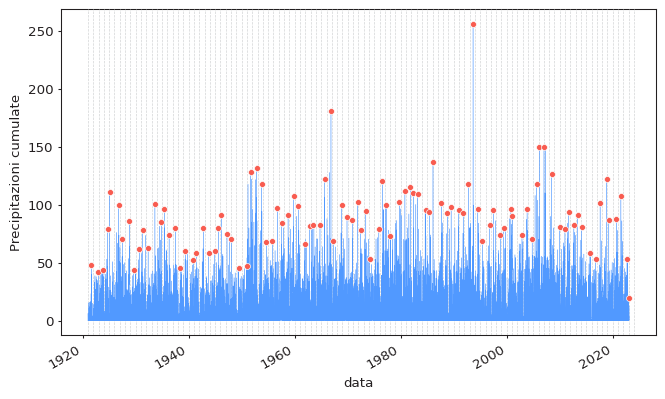

In [ ]:
# Grafico che evidenzia i valori estremi
model.plot_extremes()

In [ ]:
# Elenco dei valori estremi in ordine descrescente
model.extremes.sort_values(ascending=False)


,Precipitazioni cumulate
data,
1993-08-23,256.03
1966-11-05,180.60
2006-02-26,150.11
2007-01-10,150.10
1986-02-01,136.60
...,...
1938-06-13,45.00
1923-11-07,44.00
1929-08-22,44.00


In [ ]:
# Calcolo della media dei valori estremi
mean=np.mean(model.extremes)
print("La media dei valori estremi del modello calcolato con il metodo della Block Maxima è:", mean)

La media dei valori estremi del modello calcolato con il metodo della Block Maxima è: 88.57533980582525


In [ ]:
# Calcolo della deviazione standard
sd=np.std(model.extremes)
print("La deviazione standard dei valori estremi del modello calcolato con il metodo della Block Maxima è:", sd)

La deviazione standard dei valori estremi del modello calcolato con il metodo della Block Maxima è: 30.651385366481104


Ottimizziamo il modello con il metodo della verosimiglianza (max likelihood), in particolare l'AIC che permette di individuare il modello preferito, ossia quello che minimizza proprio il valore dell'AIC.

In [ ]:
# Ottimizzazione della likelihood con il metodo Akaike Information Criterion (AIC)
model.fit_model()

In [ ]:
# Stima dei valori attesi tra 1, 2, 5 e 10 anni, con un intervallo di confidenza di 0.95(95%) e considerando un campione di 1000 elementi
summary=model.get_summary(return_period=[1,2,5,10], alpha=0.95, n_samples=1000,)
summary

/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,return value,lower ci,upper ci
return period,,,
1.0,-inf,NaN,NaN
2.0,84.273503,79.001290,89.889511
5.0,112.742562,104.446278,120.557336
10.0,131.591557,120.853032,142.116843


(<Figure size 768x768 with 4 Axes>,
 (<Axes: title={'center': 'Return value plot'}, xlabel='Return period', ylabel='Precipitazioni cumulate'>,
  <Axes: title={'center': 'Probability density plot'}, xlabel='Precipitazioni cumulate', ylabel='Probability density'>,
  <Axes: title={'center': 'Q-Q plot'}, xlabel='Theoretical', ylabel='Observed'>,
  <Axes: title={'center': 'P-P plot'}, xlabel='Theoretical', ylabel='Observed'>))

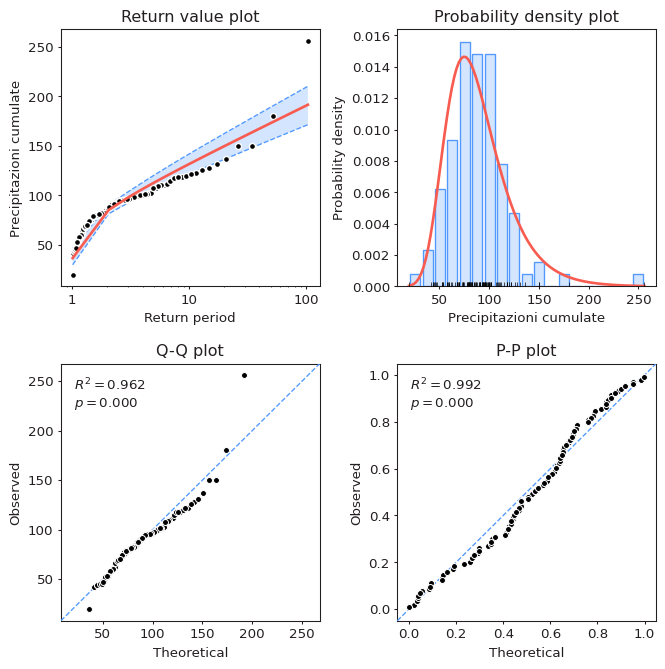

In [ ]:
# Visualizzazione di grafici sul periodo di ritorno, sulla densità di probabilità, su Q-Q plot e P-P plot
model.plot_diagnostic(alpha=0.95)

Il grafico "Return value plot" mostra un incremento del tempo di ritorno abbastanza costante e contenuto fino alle precipitazioni con un valore di 120, per poi dilagare soprattutto con i valori superiori a 150. Il grafico Q-Q plot mostra un solo valore molto lontano (circa 250) dalla distribuzione normale individuata dalla bisettrice del grafico, mentre il coefficiente di determinazione R^2, che descrive quanto i dati sono spiegati più o meno correttamente dal modello statistico , è pari a 0.962, più basso rispetto a quello del P-P plot, pari a 0.992. il P-P plot indica quanto due set di dati siano simili, uno campionario e l'altro teorico.

In [ ]:
# Distribuzione gumbel
# Parametri:c è ξ (forma, = 0 è Gumbel) loc è μ (posizione), scale è σ (dispersione)
model.distribution

         pyextremes distribution         
-----------------------------------------
name: gumbel_r                           
free parameters: loc, scale              
fixed parameters: all parameters are free
MLE parameters: loc=75.068, scale=25.118 
-----------------------------------------

Importiamo da pyextremes la funzione get_return_periods che ci permette di stimare i tempi di ritorno, in media, e la probabilità che si verifichi un evento estremo: in questo caso una precipitazione estrema del DataFrame del Trentino-Alto Adige.

In [ ]:
from pyextremes import get_return_periods
return_periods=get_return_periods(ts=data, extremes=model.extremes, extremes_method="BM", extremes_type="high", block_size="365.2425D", return_period_size="365.2425D", plotting_position="weibull",)


In [ ]:
# Visualizzazione dei primi cinque tempi di ritorno delle precipitazione più estreme
return_periods.sort_values('return period', ascending=False).head()

,Precipitazioni cumulate,exceedance probability,return period
data,,,
1993-08-23,256.03,0.009615,104.000000
1966-11-05,180.60,0.019231,52.000000
2006-02-26,150.11,0.028846,34.666667
2007-01-10,150.10,0.038462,26.000000
1986-02-01,136.60,0.048077,20.800000


Passiamo al metodo Peaks Over Threashold che ci permette di considerare i valori estremi individuati attraverso una soglia minima di riferimento; infatti, questi valori prendono il nome di "exceedances", ossia "picchi oltre la soglia".


In [ ]:
# Stesso procedimento del metodo della Block Maxima per creare il modello degli eventi estremi
model2=EVA(data)
model2.get_extremes(method="POT", threshold=100, r="30D")
# Soglia minima delle precipitazioni pari a 100 e intervallo minimo di 30 giorni per considerare due valori estremi indipendenti


(<Figure size 768x480 with 1 Axes>,
 <Axes: xlabel='data', ylabel='Precipitazioni cumulate'>)

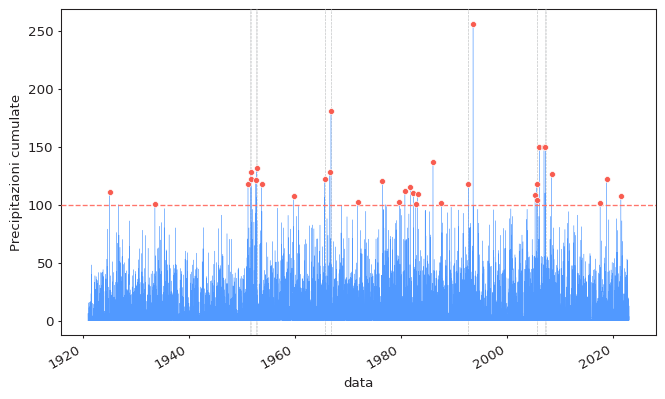

In [ ]:
# Visualizzazione dei valori estremi con il metodo della POT
model2.plot_extremes(show_clusters=True)

In [ ]:
# Elenco dei valori estremi
print("Le precipitazioni estreme rilevate sono:", len(model2.extremes))
model2.extremes

Le precipitazioni estreme rilevate sono: 34


,Precipitazioni cumulate
data,
1925-02-16,110.50
1933-08-21,100.40
1951-03-12,117.60
1951-09-02,128.00
1951-11-08,122.00
1952-08-21,121.60
1952-10-21,131.20
1953-10-16,118.20
1959-10-28,107.50


In [ ]:
# Elenco dei valori estremi in ordine decrescente
model2.extremes.sort_values(ascending=False)

,Precipitazioni cumulate
data,
1993-08-23,256.03
1966-11-05,180.60
2006-02-26,150.11
2007-01-10,150.10
2007-04-03,150.10
1986-02-01,136.60
1952-10-21,131.20
1951-09-02,128.00
1966-08-17,127.80


Considerando i valori estremi individuati con i due metodi la differenza in termini numerici è netta: 103 con la BM e 34 con la POT, che con una soglia minima di 100 non individua molti valori che presentano la densità di probabilità maggiore, come si può notare dal "Probability density plot" precedentemente visualizzato. Inoltre, considerando le medie dei due modelli di valori estremi la differenza conferma la diversa interpretazione dei dati.

In [ ]:
# Media dei valori estremi calcolati con il metodo della POT
mean2=np.mean(model2.extremes)
print("La media dei valori estremi del modello calcolato con il metodo del POT è:", mean2)

La media dei valori estremi del modello calcolato con il metodo del POT è: 123.72352941176469


In [ ]:
# Differenza tra le medie
print("La differenza tra le medie dei due modelli è pari a:", mean2-mean)

La differenza tra le medie dei due modelli è pari a: 35.148189605939436


In [ ]:
# Deviazione standard dei valori estremi
sd2=np.std(model2.extremes)
print("La deviazione standard dei valori estremi del modello calcolato con il metodo della Peaks Over Threshold è:", sd2)

La deviazione standard dei valori estremi del modello calcolato con il metodo della Peaks Over Threshold è: 28.823920405511327


In [ ]:
# Differenza tra le variazioni standard
print("La differenza tra le deviazioni standard dei due modelli è pari a:", sd2-sd)

La differenza tra le deviazioni standard dei due modelli è pari a: -1.8274649609697775


Ottimizziamo il modello utilizzando la distribuzione generalizzata di Pareto (GPD): una famiglia di distribuzione di probabilità che usa tre parametri:  ξ (forma), μ (posizione) e σ (dispersione)

In [ ]:
# Ottimizzazione della likelihood specificando di utilizzare la distribuzione GPD
# Nota: il parametro distribution_kwargs={} è necessario per evitare che il fit lavori su un location parameter prefissato
model2.fit_model(distribution="genpareto", distribution_kwargs={})

In [ ]:
# Stima dei periodi di ritorno tra 1, 2, 5 e 10 anni, con un intervallo di confidenza pari a 0.95 e considerando un campione di 1000 elementi
summary2=model2.get_summary(return_period=[1,2,5,10], alpha=0.95, n_samples=1000)
summary2

/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,return value,lower ci,upper ci
return period,,,
1.0,-inf,NaN,NaN
2.0,-inf,NaN,NaN
5.0,110.681139,78.518413,148.258373
10.0,126.368384,120.108911,206.803603


(<Figure size 768x768 with 4 Axes>,
 (<Axes: title={'center': 'Return value plot'}, xlabel='Return period', ylabel='Precipitazioni cumulate'>,
  <Axes: title={'center': 'Probability density plot'}, xlabel='Precipitazioni cumulate', ylabel='Probability density'>,
  <Axes: title={'center': 'Q-Q plot'}, xlabel='Theoretical', ylabel='Observed'>,
  <Axes: title={'center': 'P-P plot'}, xlabel='Theoretical', ylabel='Observed'>))

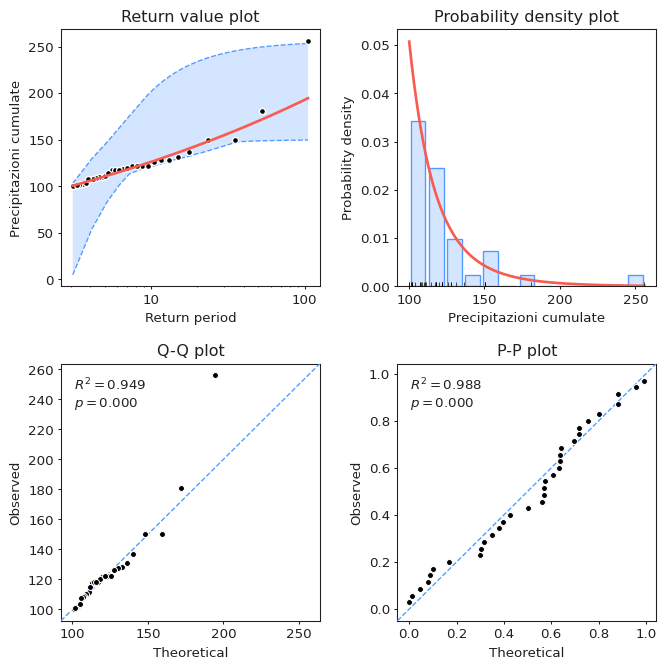

In [ ]:
# Visualizzazione di grafici sul periodo di ritorno, sulla densità di probabilità, su Q-Q plot e P-P plot
model2.plot_diagnostic(alpha=0.95)

Si può notare che con solamente 34 dati disponibili l'indice di determinazione R^2 è più basso sia nel Q-Q plot che nel P-P plot (rispettivamente 0.949 e 0.988), di conseguenza la distribuzione ottenuta è leggermente più distante dalla normale e il set di dati è dissimile da quello teorico del P-P plot.

In [ ]:
from pyextremes import get_return_periods
return_periods2=get_return_periods(ts=data, extremes=model2.extremes, extremes_method="POT", extremes_type="high", return_period_size="365.2425D", plotting_position="weibull",)

In [ ]:
# Visualizzazione dei primi cinque tempi di ritorno delle precipitazione più estreme utilizzando la POT
return_periods2.sort_values('return period', ascending=False).head()

,Precipitazioni cumulate,exceedance probability,return period
data,,,
1993-08-23,256.03,0.028571,105.068389
1966-11-05,180.60,0.057143,52.534195
2006-02-26,150.11,0.085714,35.022796
2007-01-10,150.10,0.128571,23.348531
2007-04-03,150.10,0.128571,23.348531


Facendo un confronto tra i periodi di ritorno stimati utilizzando i metodi della Block Maxima e della Peaks Over Threshold notiamo, usando i dati della POT, dei valori più elevati.

In [ ]:
# Distribuzione genpareto (GPD)
# parametri: c è ξ (forma) loc è μ (posizione), scale è σ (scala)
model2.distribution

             pyextremes distribution              
--------------------------------------------------
name: genpareto                                   
free parameters: c, loc, scale                    
fixed parameters: all parameters are free         
MLE parameters: c=0.160, loc=100.200, scale=19.715
--------------------------------------------------

Ora passiamo alla visualizzazione di alcuni grafici utili per un'analisi grafica approfondita dei valori estremi oltre una soglia.

Il primo grafico è quello della mean_residual_life che rappresenta il valore medio in eccesso rispetto ad una determinata soglia, in modo che il modello di distribuzione di Pareto sia ancora valido. Notiamo che il valore rimane stabile intorno all'eccesso di 20.

<Axes: xlabel='Threshold', ylabel='Mean excess'>

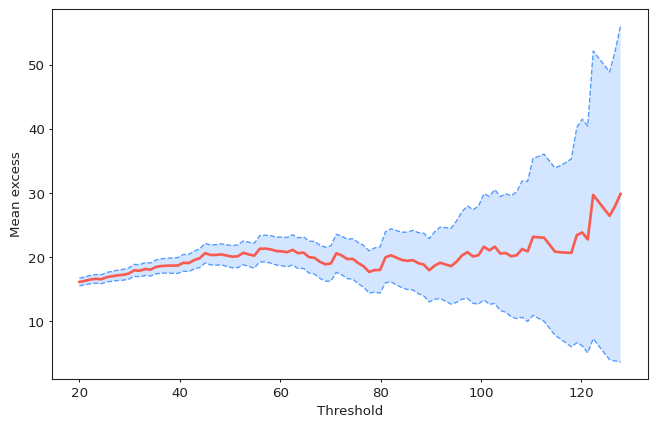

In [ ]:
# Mean Residual Life
from pyextremes import plot_mean_residual_life
plot_mean_residual_life(data)

Il secondo grafico (parameter_stability) mostra la variazione dei parametri della distribuzione generalizzata di Pareto (GDP) dentro un intervallo di soglia. Notiamo che fino alla soglia di 100 i valori sono molto stabili, mentre successivamente presentano una varianza maggiore.

(<Axes: ylabel='Shape, $\\xi$'>,
 <Axes: xlabel='Threshold', ylabel='Modified scale, $\\sigma^*$'>)

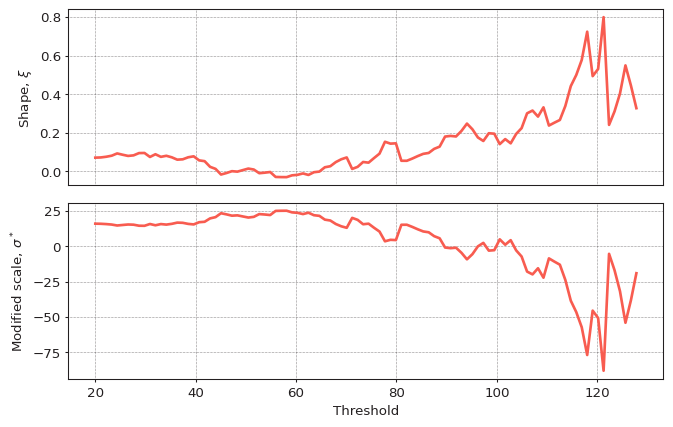

In [ ]:
# Parameter Stability
from pyextremes import plot_parameter_stability
plot_parameter_stability(data)

Il terzo grafico studia la stabilità di un valore di ritorno considerando un range di soglie.

<Axes: xlabel='Threshold', ylabel='Return value'>

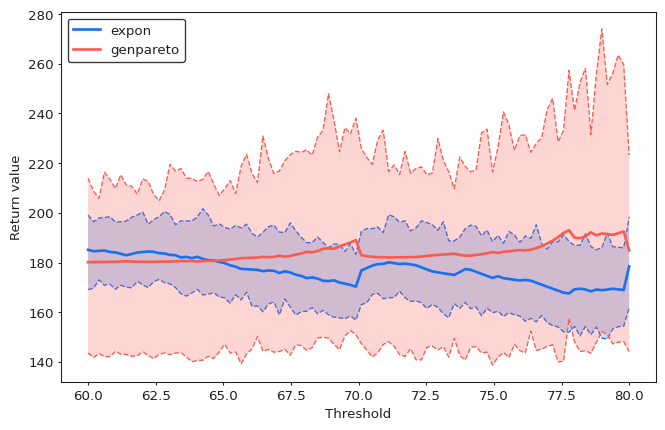

In [ ]:
# Return Value Stability
from pyextremes import plot_return_value_stability
plot_return_value_stability(data,return_period=100,thresholds=np.linspace(60, 80, 100), alpha=0.95,)


L'ultima serie di grafici racchiude tutti i grafici precedenti, ottenendo così una visione d'insieme, aggiungendo la curva AIC che indica le prestazioni del modello della distribuzione generalizzata di Pareto e del modello esponenziale.

(<Axes: ylabel='Shape, $\\xi$'>,
 <Axes: ylabel='Modified scale, $\\sigma^*$'>,
 <Axes: ylabel='Return value'>,
 <Axes: xlabel='Threshold', ylabel='AIC Score'>)

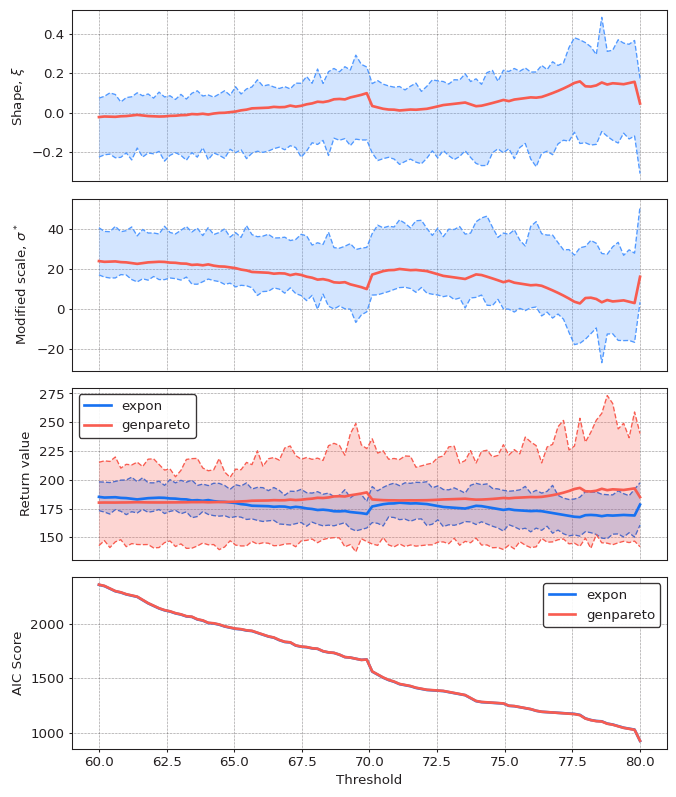

In [ ]:
from pyextremes import plot_threshold_stability
plot_threshold_stability(data, return_period=100, thresholds= np.linspace(60,80,100), alpha=0.95)

Utilizzando il metodo della POT con una soglia di riferimento pari a 50 anzichè di 100, il modello acquisice una migliore accuratezza grazie ad una maggiore quantità di valori estremi analizzati: si passa da 34 a 268 (quindi anche maggiori a quelli presenti nel primo metodo della Block Maxima). Inoltre, con 268 valori, siamo in grado di calcolare anche i tempi di ritorno relativi a 1 e 2 anni. I grafici relativi al Q-Q plot e P-P plot presentano un indice di determinazione più elevato dimostrando una maggiore rappresentazione dei dati da parte del modello.

In [ ]:
model3=EVA(data)
model3.get_extremes(method="POT", threshold=50, r="30D")

(<Figure size 768x480 with 1 Axes>,
 <Axes: xlabel='data', ylabel='Precipitazioni cumulate'>)

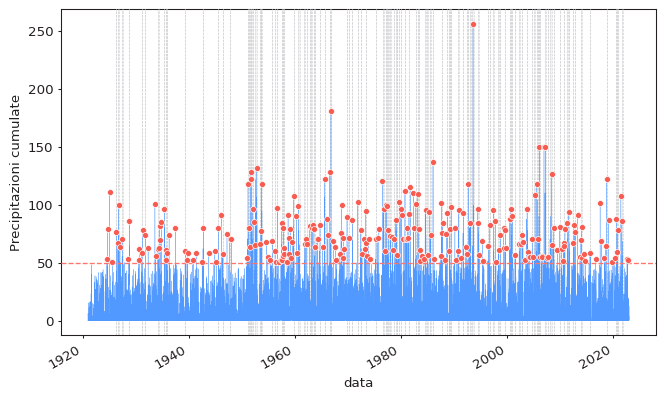

In [ ]:
model3.plot_extremes(show_clusters=True)

In [ ]:
# Elenco dei valori estremi
print("Le precipitazioni estremi del terzo modello sono:", len(model3.extremes))
model3.extremes

Le precipitazioni estremi del terzo modello sono: 268


,Precipitazioni cumulate
data,
1924-07-30,53.0
1924-09-25,78.9
1925-02-16,110.5
1925-08-03,50.8
1926-05-16,76.0
...,...
2020-12-06,77.8
2021-07-14,107.4
2021-09-19,86.1


In [ ]:
# Elenco dei valori in ordine decrescente
model3.extremes.sort_values(ascending=False)

,Precipitazioni cumulate
data,
1993-08-23,256.03
1966-11-05,180.60
2006-02-26,150.11
2007-04-03,150.10
2007-01-10,150.10
...,...
1956-07-02,50.50
1956-05-24,50.50
2019-11-16,50.20


In [ ]:
# Ottimizzazione della likelihood specificando di utilizzare la distribuzione GPD
model3.fit_model(distribution="genpareto", distribution_kwargs={})

In [ ]:
# Stima dei periodi di ritorno tra 1, 2, 5 e 10 anni, con un intervallo di confidenza pari a 0.95 e considerando un campione di 1000 elementi
summary3=model3.get_summary(return_period=[1,2,5,10], alpha=0.95, n_samples=1000)
summary3

,return value,lower ci,upper ci
return period,,,
1.0,75.817915,72.902771,97.508300
2.0,93.644983,89.708986,123.455188
5.0,116.420881,108.110295,205.676621
10.0,133.071564,119.553068,327.494523


(<Figure size 768x768 with 4 Axes>,
 (<Axes: title={'center': 'Return value plot'}, xlabel='Return period', ylabel='Precipitazioni cumulate'>,
  <Axes: title={'center': 'Probability density plot'}, xlabel='Precipitazioni cumulate', ylabel='Probability density'>,
  <Axes: title={'center': 'Q-Q plot'}, xlabel='Theoretical', ylabel='Observed'>,
  <Axes: title={'center': 'P-P plot'}, xlabel='Theoretical', ylabel='Observed'>))

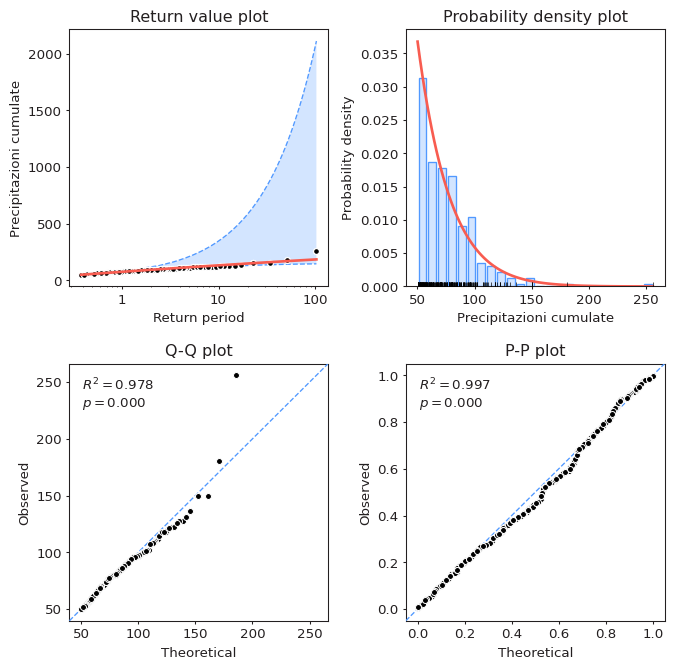

In [ ]:
# Visualizzazioni dei grafici sul periodo di ritorno, sulla densità di probabilità, su Q-Q plot e P-P plot
model3.plot_diagnostic(alpha=0.95)

In [ ]:
# Visualizzazione dei primi cinque tempi di ritorno delle precipitazione più estreme utilizzando la POT
return_periods3=get_return_periods(ts=data, extremes=model3.extremes, extremes_method="POT", extremes_type="high", return_period_size="365.2425D", plotting_position="weibull",)

In [ ]:
# Elenco dei primi cinque periodi di ritorno de cinque valori più estremi
return_periods2.sort_values('return period', ascending=False).head()

,Precipitazioni cumulate,exceedance probability,return period
data,,,
1993-08-23,256.03,0.028571,105.068389
1966-11-05,180.60,0.057143,52.534195
2006-02-26,150.11,0.085714,35.022796
2007-01-10,150.10,0.128571,23.348531
2007-04-03,150.10,0.128571,23.348531


In [ ]:
# Distribuzione genpareto (GPD)
# parametri: c è ξ (forma) loc è μ (posizione), scale è σ (scala)
model3.distribution

             pyextremes distribution              
--------------------------------------------------
name: genpareto                                   
free parameters: c, loc, scale                    
fixed parameters: all parameters are free         
MLE parameters: c=-0.042, loc=50.100, scale=27.190
--------------------------------------------------

In coclusione  il metodo della POT sembrerebbe più accurato perchè riesce a raggruppare più valori estremi del metodo della BM, che non riesce ad indiiduare i secondi valori più estremi per blocco che molto probabilmente sono considerati dal metodo della POT con soglia posizionata a 50. La difficoltà maggiore è proprio assegnare la soglia migliore per creare il modello più accurato e preciso possibile. Il primo metodo della POT con soglia pari a 100 individua un numero di valori estremi basso per una distribuizione che comprende dati ripartiti in 100 anni: 34 valori estremi comporta considerare un valore estremo in media ogni tre anni. Ma, tenendo conto della media del metodo con soglia pari a 100, posizionare la soglia a 50 comporta un modello più accurato ma, forse, fuorviante se consideriamo la definizione propria di "valore estremo".